# **PART 1 - NUMPY** **FUNDAMENTALS**

## *Q1.1 — Array Creation & Statistical Filtering*


In [32]:
import numpy as np
arr = np.linspace(0, 20, 100)
#print(len(arr))
#print(arr)


In [33]:
print("Mean:", np.mean(arr))
print("Median:", np.median(arr))
print("Std:", np.std(arr))
print("Variance:", np.var(arr))


Mean: 10.0
Median: 10.0
Std: 5.831529302570125
Variance: 34.00673400673401


 Output

Mean: 10.0  
Median: 10.0  
Std: 5.831529302570125  
Variance: 34.00673400673401


## *Q1.2 — Reshaping*


In [34]:
import numpy as np
arr = [0]*36
for i in range(0,36):
   arr[i]= i+1
Arr=np.array(arr)
print(Arr.shape)

(36,)


In [35]:
Arr= Arr.reshape(4,9)
print(Arr.shape)
Arr= Arr.reshape(-1)
print(Arr.shape)

(4, 9)
(36,)


# **PART 2 - PANDAS & DATA WRANGLING**


## Q2.1 — First Look


In [36]:
import seaborn as sns
df=sns.load_dataset('titanic')

#displaying 5 rows
print(df.head(5))



   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  


In [37]:
#using info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [38]:
#using desribe
df.describe(include='all')

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
count,891.000000,891.000000,891,714.000000,891.000000,891.000000,891.000000,889,891,891,891,203,889,891,891
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,3,3,3,2,7,3,2,2
top,NaN,NaN,male,NaN,NaN,NaN,NaN,S,Third,man,True,C,Southampton,no,True
freq,NaN,NaN,577,NaN,NaN,NaN,NaN,644,491,537,537,59,644,549,537
mean,0.383838,2.308642,NaN,29.699118,0.523008,0.381594,32.204208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.486592,0.836071,NaN,14.526497,1.102743,0.806057,49.693429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,1.000000,NaN,0.420000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,0.000000,2.000000,NaN,20.125000,0.000000,0.000000,7.910400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,0.000000,3.000000,NaN,28.000000,0.000000,0.000000,14.454200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.000000,3.000000,NaN,38.000000,1.000000,0.000000,31.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Q2.2 — Missing Value Treatment


column with missing values along with their count and percentage missing

In [39]:
for col in df.columns:
    if df[col].isnull().sum():
        print(col, df[col].isnull().sum(),round((df[col].isnull().sum() / len(df)) * 100,2))
#only gives the columns where there are missing values
# missing = df.isnull().sum()
# missing % = (df.isnull().sum() / len(df)) * 100

age 177 19.87
embarked 2 0.22
deck 688 77.22
embark_town 2 0.22


filling missing values in the age column with the median age

In [40]:
def fill_with_median(x):
    return x.fillna(x.median())
df['age']= df.groupby('pclass')['age'].transform( fill_with_median)

filling missing values in the embark column with the mode

In [41]:
df['embarked']= df['embarked'].fillna(df['embarked'].mode()[0])

Dropping the deck column  
why?- it has 77% values missing, making it unreliable and may introduce bias

In [42]:
df = df.drop(columns=['deck'])

verification

In [43]:
print(df[['age','embarked']].isnull().sum())
#verification successful when sum = 0

age         0
embarked    0
dtype: int64


# **Part 3 — Matplotlib Visualizations**

## *Q3.1 — Histogram*

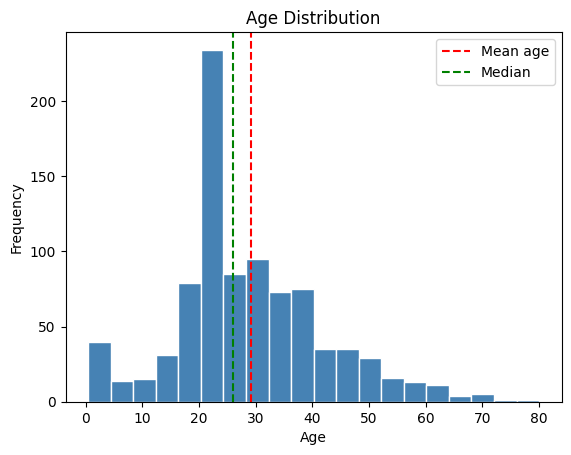

In [44]:
import matplotlib.pyplot as plt

# Calculate mean and median
mean_age = df['age'].mean()
median_age = df['age'].median()

# Create histogram
plt.hist(df['age'],bins=20,color='steelblue',edgecolor='white')

#mean line
plt.axvline(mean_age,color='red',linestyle='--',label='Mean age')

#median line
plt.axvline(median_age,color='green',linestyle='dashed',label='Median')

# Labels and legend
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Age Distribution')
plt.legend()

plt.show()


## *Q3.2 — Scatter Plot with Color Encoding*

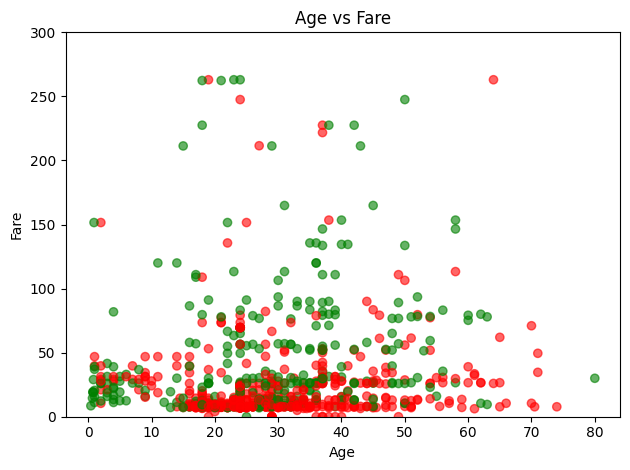

In [45]:
# Create colors based on survival
colors = df['survived'].map({0: 'red', 1: 'green'})
#scatter plot
plt.scatter(df['age'],df['fare'],c=colors,alpha=0.6)
#cap  y
plt.ylim(0,300)
# Labels and title
plt.xlabel('Age')
plt.ylabel('Fare')
plt.title('Age vs Fare')


plt.tight_layout()
plt.show()

# **Part 4 — Exploratory Data Analysis**

## # *Q4.1 — Initial Inspection*

In [74]:
import pandas as pd
df = pd.read_csv("advertising.csv" )

# 1. Shape
print("Shape:", df.shape)

# 2. Data types
print("\nData Types:")
print(df.dtypes)

# 3. Missing values
print("\nMissing Values:")
print(df.isnull().sum())



Shape: (200, 4)

Data Types:
TV           float64
Radio        float64
Newspaper    float64
Sales        float64
dtype: object

Missing Values:
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64


In [53]:
# 4.describe()
print("\nDescribe:")
print(df.describe())




Describe:
               TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000
mean   147.042500   23.264000   30.554000   15.130500
std     85.854236   14.846809   21.778621    5.283892
min      0.700000    0.000000    0.300000    1.600000
25%     74.375000    9.975000   12.750000   11.000000
50%    149.750000   22.900000   25.750000   16.000000
75%    218.825000   36.525000   45.100000   19.050000
max    296.400000   49.600000  114.000000   27.000000


**TV**  
*Range:* 295.70
*Spread (Std Dev):* 85.85

**Radio**  
*Range:* 49.60
*Spread (Std Dev):* 14.85

**Newspaper**  
*Range:* 113.70
*Spread (Std Dev):* 21.78

**Sales**  
*Range:* 25.40
*Spread (Std Dev):* 5.28

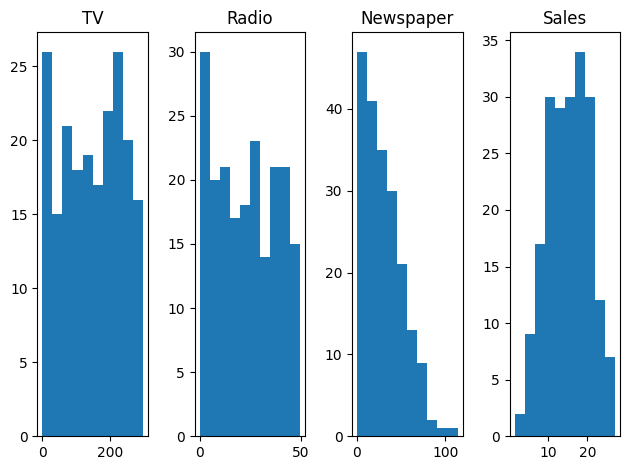

In [49]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 4)

ax[0].hist(df['TV'])
ax[0].set_title('TV')

ax[1].hist(df['Radio'])
ax[1].set_title('Radio')

ax[2].hist(df['Newspaper'])
ax[2].set_title('Newspaper')

ax[3].hist(df['Sales'])
ax[3].set_title('Sales')

plt.tight_layout()
plt.show()

In the **sales' histogram**, the peak (the maximum number of observations is near the median value) suggesting that in every data point the advertisement combination is such a way which is resulting in consistent sales of the product.

And in every histogram we find that a peak is reached near the lowest spending (specially the outlier in **TV** and **Radio**) suggesting the advertisement strategy maybe be more focussed in one or two of the advertisements in every data pt, as the sales peak is at median indicating fairly consistent sales. And another peak near 200 for **TV** may suggest more consistent focus in TV compared to the rest 2.


And the steady decrease in the **Newspaper's** suggests lower inclination for advertisement there



## *Q4.2 — Correlation Analysis*

In [50]:
corr = df.corr(numeric_only=True)

print(corr)


                 TV     Radio  Newspaper     Sales
TV         1.000000  0.054809   0.056648  0.901208
Radio      0.054809  1.000000   0.354104  0.349631
Newspaper  0.056648  0.354104   1.000000  0.157960
Sales      0.901208  0.349631   0.157960  1.000000


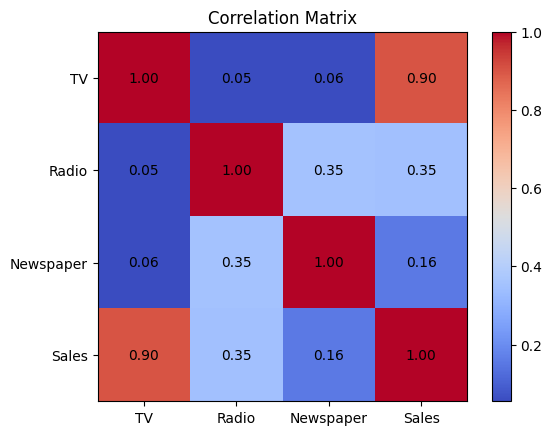

In [60]:
corr = df.corr(numeric_only=True)

im = plt.imshow(corr, cmap='coolwarm')

plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns)
plt.yticks(range(len(corr.columns)), corr.columns)

for i in range(len(corr)):
    for j in range(len(corr)):
        plt.text(j,i,f"{corr.iloc[i,j]:.2f}",ha='center', va='center' )

plt.title("Correlation Matrix")
plt.show()

**TV** is most correlated with **sales**

**TV** and **Radio** correlation is very small equalling 0.05 can be almost considere uncorrelated



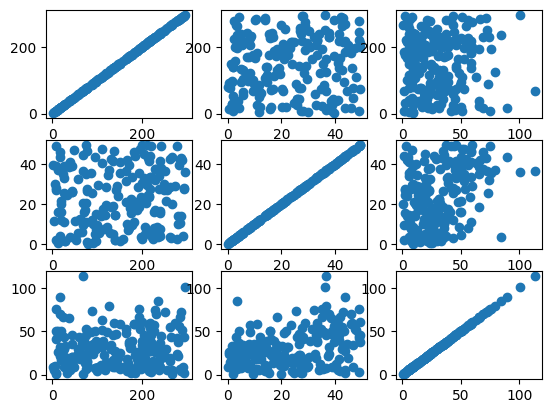

In [63]:
fig, ax = plt.subplots(3,3)

cols = ['TV','Radio','Newspaper']

for i in range(3):
    for j in range(3):
        ax[i,j].scatter(df[cols[j]],df[cols[i]])

#  **Part 5 — Linear Regression**

# *Q5.1 — Scratch Implementation: Simple Linear Regression*


In [64]:
X = df['TV'].values
y = df['Sales'].values

# Split
X_train = X[:160]
y_train = y[:160]
X_test = X[160:]
y_test = y[160:]

# Means
x_bar = np.mean(X_train)
y_bar = np.mean(y_train)

# Slope
m = np.sum((X_train - x_bar) * (y_train - y_bar)) / \
    np.sum((X_train - x_bar) ** 2)

# Intercept
b = y_bar - m * x_bar

print("Slope (m):", m)
print("Intercept (b):", b)




Slope (m): 0.05572601895005874
Intercept (b): 6.993686960994353


In [65]:
# Predictions
y_pred = m * X_test + b


In [66]:
# MSE
mse = np.mean((y_test - y_pred) ** 2)

print("MSE:", mse)

MSE: 5.459799471482253


# *Q5.2 — Sklearn Implementation*

In [67]:
from sklearn.model_selection import train_test_split

X = df[['TV']]
y = df['Sales']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [70]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train);

In [71]:
print("Coefficient (m):", model.coef_[0])
print("Intercept (b):", model.intercept_)

Coefficient (m): 0.0554829439314632
Intercept (b): 7.007108428241848


Since the training data differs, the estimated regression line also differs slightly.

## *Q5.3 — Evaluation Metrics*


In [72]:
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

#MAE
from sklearn.metrics import mean_absolute_error

train_mae = mean_absolute_error(y_train, y_pred_train)
test_mae = mean_absolute_error(y_test, y_pred_test)

#MSE
from sklearn.metrics import mean_squared_error

train_mse = mean_squared_error(y_train, y_pred_train)
test_mse = mean_squared_error(y_test, y_pred_test)

#RMSE
train_rmse = np.sqrt(train_mse)
test_rmse = np.sqrt(test_mse)

#R^2
from sklearn.metrics import r2_score

train_r2 = r2_score(y_train, y_pred_train)
test_r2 = r2_score(y_test, y_pred_test)

In [73]:
print("TRAIN")

print("MAE :", train_mae)
print("MSE :", train_mse)
print("RMSE:", train_rmse)
print("R²  :", train_r2)

print("\nTEST")

print("MAE :", test_mae)
print("MSE :", test_mse)
print("RMSE:", test_rmse)
print("R²  :", test_r2)

TRAIN
MAE : 1.8005092256620792
MSE : 4.998442356450173
RMSE: 2.235719650683013
R²  : 0.8134866044709264

TEST
MAE : 1.9502948931650088
MSE : 6.101072906773963
RMSE: 2.470035001123256
R²  : 0.802561303423698


The model is well-fit because the training and testing performance are similar, indicating good generalization.

# **Part 6 — K-Means Clustering**

## *Q6.1 — Data Exploration*

In [77]:
df = pd.read_csv("Mall_Customers.csv" )

#head
print(df.head())
print("\n\n")

#info
print(df.info())
print("\n\n")

#describe
print(df.describe())


   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None



       CustomerID         Age  Annual Income 

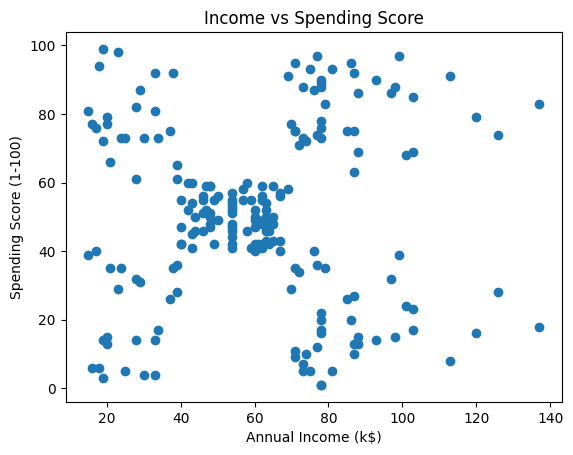

In [78]:

plt.scatter(
    df['Annual Income (k$)'],
    df['Spending Score (1-100)']
)

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Income vs Spending Score')

plt.show()

We can see around 5 natural groupings which are -

High Income, High Spending

Low Income, High Spending

Middle Group

Low Income, Low Spending

High Income, Low Spending

## *Q6.2 — Apply K-Means*

In [79]:
from sklearn.cluster import KMeans

X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

wcss = []

for k in range(1,11):
    kmeans = KMeans(n_clusters=k,random_state=42,n_init=10)

    kmeans.fit(X)

    wcss.append(kmeans.inertia_)

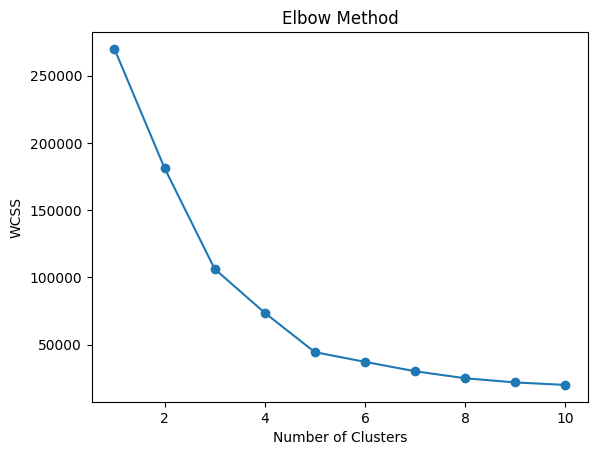

In [80]:
plt.plot(range(1,11), wcss, marker='o')

plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method')

plt.show()

In [81]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

df['Cluster'] = kmeans.fit_predict(X)

In [83]:
centroids = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=[
        'Annual Income (k$)',
        'Spending Score (1-100)'
    ]
)

print(centroids)

   Annual Income (k$)  Spending Score (1-100)
0           55.296296               49.518519
1           86.538462               82.128205
2           25.727273               79.363636
3           88.200000               17.114286
4           26.304348               20.913043


In [86]:
cluster_summary = df.groupby('Cluster').agg({'CustomerID':'count', 'Annual Income (k$)':'mean','Spending Score (1-100)':'mean'})

cluster_summary.columns = ['Customer Count','Mean Income','Mean Spending Score']

print(cluster_summary)

         Customer Count  Mean Income  Mean Spending Score
Cluster                                                  
0                    81    55.296296            49.518519
1                    39    86.538462            82.128205
2                    22    25.727273            79.363636
3                    35    88.200000            17.114286
4                    23    26.304348            20.913043


# **Part 7 — Neural Networks on MNIST**


## *Q7.1 — Data Loading & Preprocessing*

In [88]:
from tensorflow.keras.datasets import mnist

(X_train, y_train), (X_test, y_test) = mnist.load_data()

#print shapes
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
X_train: (60000, 28, 28)
y_train: (60000,)
X_test: (10000, 28, 28)
y_test: (10000,)


In [89]:
#normalize
X_train = X_train / 255.0
X_test = X_test / 255.0

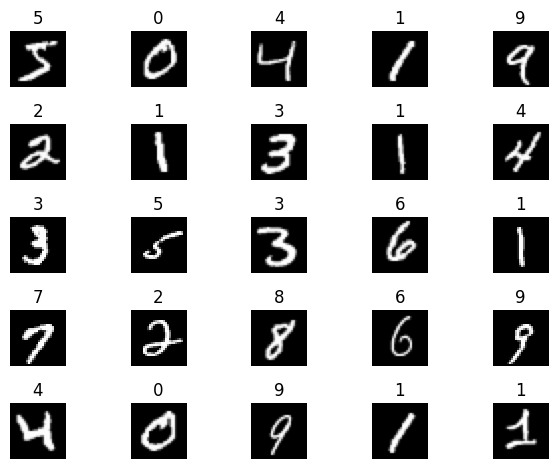

In [90]:
#Displaying
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(y_train[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

# *Q7.2 — Feedforward Neural Network*


In [91]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

model = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

#compile
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


history = model.fit(
    X_train,
    y_train,
    epochs=15,
    validation_split=0.2
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9243 - loss: 0.2617 - val_accuracy: 0.9579 - val_loss: 0.1374
Epoch 2/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9657 - loss: 0.1141 - val_accuracy: 0.9671 - val_loss: 0.1137
Epoch 3/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9757 - loss: 0.0774 - val_accuracy: 0.9680 - val_loss: 0.1044
Epoch 4/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9810 - loss: 0.0584 - val_accuracy: 0.9699 - val_loss: 0.0975
Epoch 5/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9856 - loss: 0.0457 - val_accuracy: 0.9730 - val_loss: 0.0991
Epoch 6/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9880 - loss: 0.0378 - val_accuracy: 0.9728 - val_loss: 0.0973
Epoch 7/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9906 - loss: 0.0283 - val_accuracy: 0.9732 - val_loss: 0.0968
Epoch 8/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9915 - loss: 0.0263

## *Q7.3 — Evaluation & Error Analysis*)

In [92]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9746 - loss: 0.1179
Test Loss: 0.11785859614610672
Test Accuracy: 0.9746000170707703


In [93]:
y_pred_prob = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [94]:
print(y_pred_prob.shape)

(10000, 10)


In [96]:
import numpy as np

y_pred = np.argmax(
    y_pred_prob,
    axis=1
)

In [97]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[ 967    0    2    0    3    0    4    1    2    1]
 [   0 1125    2    2    0    0    2    1    3    0]
 [   2    0 1015    2    2    1    3    4    3    0]
 [   0    0    7  964    1   18    0    8    7    5]
 [   1    0    6    0  959    0    2    4    0   10]
 [   4    0    1    1    1  867    8    1    5    4]
 [   2    2    0    0   10    3  941    0    0    0]
 [   1    2   21    1    2    0    0  994    3    4]
 [   2    1    4    5    6    3    7    4  939    3]
 [   1    4    0    2   13    3    2    8    1  975]]


In [98]:
print(cm.shape)


(10, 10)


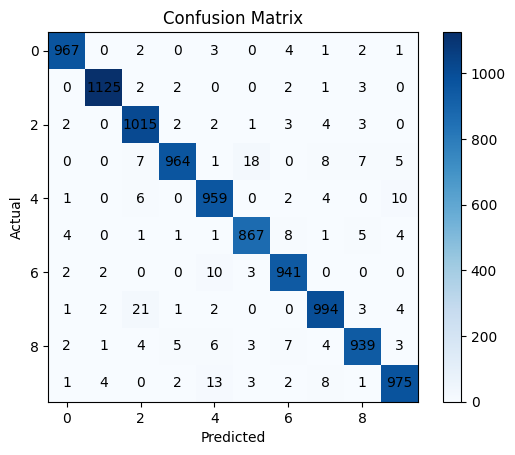

In [100]:
#Heatmap
plt.imshow(
    cm,
    cmap='Blues'
)

plt.colorbar()

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

for i in range(10):
    for j in range(10):
        plt.text(j,i,cm[i,j],ha='center',va='center')

plt.show()

## *Q7.4 — Convolutional Neural Network*


In [101]:
X_train_cnn = X_train.reshape(-1, 28, 28, 1)
X_test_cnn = X_test.reshape(-1, 28, 28, 1)

print(X_train_cnn.shape)

(60000, 28, 28, 1)


In [102]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense
)

cnn = Sequential([

    Conv2D(
        32,
        kernel_size=(3,3),
        activation='relu',
        input_shape=(28,28,1)
    ),

    MaxPooling2D(pool_size=(2,2)),

    Conv2D(
        64,
        kernel_size=(3,3),
        activation='relu'
    ),

    MaxPooling2D(pool_size=(2,2)),

    Flatten(),

    Dense(128, activation='relu'),

    Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [103]:
cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [104]:
cnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [105]:
#Train
history_cnn = cnn.fit(
    X_train_cnn,
    y_train,
    epochs=10,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 53s 34ms/step - accuracy: 0.9548 - loss: 0.1469 - val_accuracy: 0.9772 - val_loss: 0.0786
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 60s 40ms/step - accuracy: 0.9849 - loss: 0.0464 - val_accuracy: 0.9880 - val_loss: 0.0417
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 51s 34ms/step - accuracy: 0.9901 - loss: 0.0309 - val_accuracy: 0.9902 - val_loss: 0.0344
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 59s 39ms/step - accuracy: 0.9927 - loss: 0.0218 - val_accuracy: 0.9893 - val_loss: 0.0373
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 90s 45ms/step - accuracy: 0.9947 - loss: 0.0159 - val_accuracy: 0.9898 - val_loss: 0.0363
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 46s 30ms/step - accuracy: 0.9956 - loss: 0.0131 - val_accuracy: 0.9898 - val_loss: 0.0377
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 47s 32ms/step - accuracy: 0.9967 - loss: 0.0094 - val_accuracy: 0.9899 - val_loss: 0.0400
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 46s 31ms/step - accuracy: 0.9968 -

In [106]:
#Testing accuracy
test_loss_cnn, test_acc_cnn = cnn.evaluate(
    X_test_cnn,
    y_test
)

print("Test Accuracy:", test_acc_cnn)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9919 - loss: 0.0379
Test Accuracy: 0.9919000267982483


In [109]:
ff_params = model.count_params()

cnn_params = cnn.count_params()

ff_train_acc = history.history['accuracy'][-1]
ff_val_acc = history.history['val_accuracy'][-1]

cnn_train_acc = history_cnn.history['accuracy'][-1]
cnn_val_acc = history_cnn.history['val_accuracy'][-1]

ff_test_acc = test_accuracy


#comparision table
comparison = pd.DataFrame({
    'Model': ['Feedforward NN','CNN'],

    'Parameters': [ff_params,cnn.count_params()],

    'Train Acc': [ff_train_acc,cnn_train_acc],

    'Val Acc': [ff_val_acc,cnn_val_acc],

    'Test Acc': [ff_test_acc,test_acc_cnn],

    'Epochs': [15,10]
})

print(comparison)

            Model  Parameters  Train Acc   Val Acc  Test Acc  Epochs
0  Feedforward NN      109386   0.996396  0.974167    0.9746      15
1             CNN      225034   0.998208  0.991583    0.9919      10


Dense networks flatten the image and lose this spatial information whereas CNN through convulation layer and learn patterns such as curves, edges ,shapes etc and can also reduce the number of parameters and imrpove generalization.